# P1 & P2 – Cinemática del MyCobot 280
**Examen Grupal ROB 2026 – Rol: Especialista en Cinemática**

- **P1**: Representación cinemática (DH) — ítems 1 al 5
- **P2**: Cinemática directa (FK) — ítems 1 al 5

In [ ]:
# ── Librerías globales (correr primero) ──────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import radians, cos, sin

print('Librerías cargadas ✓')

Librerías cargadas ✓


---
# P1 – Representación cinemática (DH)

## P1 – Ítem 1: Identificar los 6 sistemas de referencia según la convención DH

El MyCobot 280 es un brazo serial de **6 grados de libertad**. Según la convención DH,
se asigna un sistema de referencia {i} a cada joint, con el eje **Z_i** alineado al eje de rotación
de la articulación i, y el eje **X_i** perpendicular a Z_{i-1} y Z_i.

| Frame | Ubicación física | Eje Z_i |
|-------|------------------|---------|
| {0}   | Base fija (mundo) | Vertical ↑ |
| {1}   | J1 – Base rotante | Vertical ↑ |
| {2}   | J2 – Hombro       | Horizontal (perpendicular al plano sagital) |
| {3}   | J3 – Codo         | Mismo eje que Z_2 (paralelo) |
| {4}   | J4 – Muñeca 1     | Perpendicular a Z_3 |
| {5}   | J5 – Muñeca 2     | Perpendicular a Z_4 |
| {6}   | J6 – Gripper/TCP  | Colineal con el eje de la herramienta |

La cadena cinemática es: **{0} → {1} → {2} → {3} → {4} → {5} → {6}**

## P1 – Ítem 2: Construir la tabla de parámetros DH

Cada eslabón queda definido por 4 parámetros DH más el rango articular:

| Símbolo | Significado |
|---------|-------------|
| `a_i`   | Distancia entre ejes Z_{i-1} y Z_i a lo largo de X_i (longitud eslabón) |
| `d_i`   | Distancia entre ejes X_{i-1} y X_i a lo largo de Z_i (offset articular) |
| `α_i`   | Ángulo entre Z_{i-1} y Z_i medido en torno a X_i (torsión) |
| `θ_i`   | Ángulo articular variable + offset para alinear cero físico con modelo DH |

In [ ]:
# P1 – Ítem 2: Tabla de parámetros DH del MyCobot 280
# Formato por fila: (a_mm, d_mm, alpha_deg, theta_offset_deg)
# theta_offset: corrección fija para que HOME=[0,0,0,0,0,0] coincida con el robot real

DH_TABLE = [
    (   0,   134.75,  90.0,   0.0),   # J1 – Base
    (-110,     0.0,   0.0,  -90.0),   # J2 – Hombro
    ( -96,     0.0,   0.0,    0.0),   # J3 – Codo
    (   0,    63.40,  90.0,  -90.0),  # J4 – Muñeca 1
    (   0,    75.05, -90.0,   90.0),  # J5 – Muñeca 2
    (   0,    50.00,   0.0,    0.0),  # J6 – Gripper
]

JOINT_NAMES  = ['J1 Base', 'J2 Hombro', 'J3 Codo',
                'J4 Muñeca1', 'J5 Muñeca2', 'J6 Gripper']

JOINT_LIMITS = [
    (-168, 168), (-135, 90), (-150, 150),
    (-145, 145), (-165, 165), (-180, 180),
]

df_dh = pd.DataFrame(
    [(JOINT_NAMES[i],
      DH_TABLE[i][0],
      DH_TABLE[i][1],
      DH_TABLE[i][2],
      f'q{i+1}{DH_TABLE[i][3]:+.0f}°' if DH_TABLE[i][3] != 0 else f'q{i+1}',
      f'{JOINT_LIMITS[i][0]}..{JOINT_LIMITS[i][1]}')
     for i in range(6)],
    columns=['Joint', 'a_i (mm)', 'd_i (mm)', 'α_i (°)', 'θ_i', 'Rango (°)']
)
print('=== P1 – Tabla de parámetros DH – MyCobot 280 ===')
print(df_dh.to_string(index=False))

=== P1 – Tabla de parámetros DH – MyCobot 280 ===
     Joint  a_i (mm)  d_i (mm)  α_i (°)    θ_i Rango (°)
   J1 Base         0    134.75     90.0     q1 -168..168
 J2 Hombro      -110      0.00      0.0 q2-90°  -135..90
   J3 Codo       -96      0.00      0.0     q3 -150..150
J4 Muñeca1         0     63.40     90.0 q4-90° -145..145
J5 Muñeca2         0     75.05    -90.0 q5+90° -165..165
J6 Gripper         0     50.00      0.0     q6 -180..180


## P1 – Ítem 3: Derivar la matriz de transformación homogénea Ti para cada joint

La matriz DH para el eslabón i es:

$$T_i(\theta_i) = \begin{pmatrix}
\cos\theta_i & -\sin\theta_i\cos\alpha_i &  \sin\theta_i\sin\alpha_i & a_i\cos\theta_i \\
\sin\theta_i &  \cos\theta_i\cos\alpha_i & -\cos\theta_i\sin\alpha_i & a_i\sin\theta_i \\
0            &  \sin\alpha_i             &  \cos\alpha_i             & d_i \\
0            &  0                        &  0                        & 1
\end{pmatrix}$$

In [ ]:
# P1 – Ítem 3: Función dh_matrix y cálculo de las 6 matrices Ti

def dh_matrix(theta_deg, d, a, alpha_deg):
    """
    Matriz de transformación homogénea DH 4x4 para un eslabón.
    theta_deg = ángulo articular + offset fijo del joint.
    """
    theta = radians(theta_deg)
    alpha = radians(alpha_deg)
    ct, st = cos(theta), sin(theta)
    ca, sa = cos(alpha), sin(alpha)
    return np.array([
        [ct, -st*ca,  st*sa, a*ct],
        [st,  ct*ca, -ct*sa, a*st],
        [ 0,     sa,     ca,    d],
        [ 0,      0,      0,    1],
    ], dtype=float)


def build_Ti_list(thetas_deg):
    """Devuelve lista de 6 matrices Ti para los ángulos dados."""
    return [
        dh_matrix(thetas_deg[i] + DH_TABLE[i][3],
                  DH_TABLE[i][1],
                  DH_TABLE[i][0],
                  DH_TABLE[i][2])
        for i in range(6)
    ]


# Mostrar las 6 matrices Ti en HOME
print('=== P1 – Ítem 3: Matrices Ti en pose HOME [0,0,0,0,0,0] ===\n')
for i, Ti in enumerate(build_Ti_list([0]*6)):
    print(f'T{i+1} – {JOINT_NAMES[i]}:')
    print(np.round(Ti, 4))
    print()

=== P1 – Ítem 3: Matrices Ti en pose HOME [0,0,0,0,0,0] ===

T1 – J1 Base:
[[  1.    -0.     0.     0.  ]
 [  0.     0.    -1.     0.  ]
 [  0.     1.     0.   134.75]
 [  0.     0.     0.     1.  ]]

T2 – J2 Hombro:
[[  0.   1.  -0.  -0.]
 [ -1.   0.  -0. 110.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]

T3 – J3 Codo:
[[  1.  -0.   0. -96.]
 [  0.   1.  -0.  -0.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]

T4 – J4 Muñeca1:
[[ 0.   0.  -1.   0. ]
 [-1.   0.  -0.  -0. ]
 [ 0.   1.   0.  63.4]
 [ 0.   0.   0.   1. ]]

T5 – J5 Muñeca2:
[[ 0.   -0.   -1.    0.  ]
 [ 1.    0.    0.    0.  ]
 [ 0.   -1.    0.   75.05]
 [ 0.    0.    0.    1.  ]]

T6 – J6 Gripper:
[[ 1. -0.  0.  0.]
 [ 0.  1. -0.  0.]
 [ 0.  0.  1. 50.]
 [ 0.  0.  0.  1.]]



## P1 – Ítem 4: Verificar que T06 en HOME reproduce la posición de referencia del robot

In [ ]:
# P1 – Ítem 4: Verificación con robot real en pose HOME

from pymycobot.mycobot import MyCobot
import time

mc = MyCobot('/dev/ttyUSB0', 1000000)
mc.power_on()
time.sleep(1)
assert mc.is_controller_connected(), 'Error de conexión'
print('Robot conectado ✓')

# Función FK completa
def forward_kinematics(thetas_deg):
    """Devuelve T06 (4x4). Posición del extremo = T06[0:3, 3]"""
    T = np.eye(4)
    for Ti in build_Ti_list(thetas_deg):
        T = T @ Ti
    return T

def get_xyz(T06):
    return T06[0, 3], T06[1, 3], T06[2, 3]

# Mover a HOME y leer posición real
mc.send_angles([0, 0, 0, 0, 0, 0], 25)
time.sleep(4)
coords_real = mc.get_coords()   # [x, y, z, rx, ry, rz]

# FK calculada en HOME
T06_home = forward_kinematics([0, 0, 0, 0, 0, 0])
x_c, y_c, z_c = get_xyz(T06_home)

# Comparación
error = np.linalg.norm([x_c - coords_real[0],
                        y_c - coords_real[1],
                        z_c - coords_real[2]])

print(f'Posición real  (get_coords): x={coords_real[0]:.2f},  y={coords_real[1]:.2f},  z={coords_real[2]:.2f} mm')
print(f'Posición FK calculada:       x={x_c:.2f},  y={y_c:.2f},  z={z_c:.2f} mm')
print(f'\nError euclidiano: {error:.2f} mm')
print(f'  Δx = {abs(x_c - coords_real[0]):.2f} mm')
print(f'  Δy = {abs(y_c - coords_real[1]):.2f} mm')
print(f'  Δz = {abs(z_c - coords_real[2]):.2f} mm')
print(f'\nMatriz T06 completa en HOME:')
print(np.round(T06_home, 4))

Robot conectado ✓
Posición real  (get_coords): x=53.40,  y=-64.60,  z=408.30 mm
Posición FK calculada:       x=50.00,  y=-63.40,  z=415.80 mm

Error euclidiano: 8.32 mm
  Δx = 3.40 mm
  Δy = 1.20 mm
  Δz = 7.50 mm

Matriz T06 completa en HOME:
[[ -0.    0.    1.   50. ]
 [ -1.   -0.   -0.  -63.4]
 [ -0.   -1.    0.  415.8]
 [  0.    0.    0.    1. ]]


## P1 – Ítem 5: Significado físico de cada parámetro DH en el MyCobot 280

In [ ]:
# P1 – Ítem 5: Documentación del significado físico de los parámetros DH

significados = [
    ('J1 Base',
     'd1=134.75 mm',
     'Altura de la base hasta el primer eje de rotación. '
     'α1=90°: el eje de J2 es perpendicular al de J1, permitiendo rotación horizontal completa.'),
    ('J2 Hombro',
     'a2=-110 mm',
     'Longitud del primer eslabón (hombro). Negativo porque el eje X apunta en sentido contrario. '
     'α2=0°: J2 y J3 son paralelos → movimiento planar. Controla la elevación del codo.'),
    ('J3 Codo',
     'a3=-96 mm',
     'Longitud del segundo eslabón (antebrazo). '
     'α3=0°: eje paralelo a J2. Dobla el codo del robot.'),
    ('J4 Muñeca 1',
     'd4=63.40 mm',
     'Offset axial de la primera articulación de muñeca. '
     'α4=90°: gira el plano de movimiento para habilitar orientación. Primer DOF de orientación.'),
    ('J5 Muñeca 2',
     'd5=75.05 mm',
     'Offset axial de la segunda muñeca. '
     'α5=-90°: invierte el plano para el siguiente eje. Controla el pitch de la herramienta.'),
    ('J6 Gripper',
     'd6=50.00 mm',
     'Distancia del último joint al TCP (Tool Center Point). '
     'α6=0°: eje colineal con la herramienta. Controla el roll (rotación) del gripper.'),
]

print('=== P1 – Ítem 5: Significado físico de los parámetros DH ===')
for name, param, desc in significados:
    print(f'\n[{name}] – {param}')
    print(f'  {desc}')

=== P1 – Ítem 5: Significado físico de los parámetros DH ===

[J1 Base] – d1=134.75 mm
  Altura de la base hasta el primer eje de rotación. α1=90°: el eje de J2 es perpendicular al de J1, permitiendo rotación horizontal completa.

[J2 Hombro] – a2=-110 mm
  Longitud del primer eslabón (hombro). Negativo porque el eje X apunta en sentido contrario. α2=0°: J2 y J3 son paralelos → movimiento planar. Controla la elevación del codo.

[J3 Codo] – a3=-96 mm
  Longitud del segundo eslabón (antebrazo). α3=0°: eje paralelo a J2. Dobla el codo del robot.

[J4 Muñeca 1] – d4=63.40 mm
  Offset axial de la primera articulación de muñeca. α4=90°: gira el plano de movimiento para habilitar orientación. Primer DOF de orientación.

[J5 Muñeca 2] – d5=75.05 mm
  Offset axial de la segunda muñeca. α5=-90°: invierte el plano para el siguiente eje. Controla el pitch de la herramienta.

[J6 Gripper] – d6=50.00 mm
  Distancia del último joint al TCP (Tool Center Point). α6=0°: eje colineal con la herramienta.

---
# P2 – Cinemática Directa (FK)

## P2 – Ítem 1: Implementar T06 = T1·T2·T3·T4·T5·T6 en Python con numpy

$$T_0^6 = T_1 \cdot T_2 \cdot T_3 \cdot T_4 \cdot T_5 \cdot T_6$$

La posición del extremo `(x, y, z)` corresponde a la última columna de T06, filas 0–2.

In [ ]:
# P1 – Ítem 3 (DETALLADO): cada Tn individual + acumulación hasta T06

def print_matrix(name, M, decimals=4):
    """Imprime una matriz 4x4 con formato limpio."""
    print(f'\n{'─'*50}')
    print(f'  {name}')
    print(f'{'─'*50}')
    for row in M:
        formatted = '  '.join(f'{v:+.{decimals}f}' for v in row)
        print(f'  [ {formatted} ]')

# ── Pose HOME ──────────────────────────────────────────────────────────────
THETAS_HOME = [0, 0, 0, 0, 0, 0]

# Calculamos las 6 matrices individuales
Ti_list = build_Ti_list(THETAS_HOME)

print('=' * 50)
print('  MyCobot 280 – Matrices Ti individuales (HOME)')
print('=' * 50)

for i, (Ti, name) in enumerate(zip(Ti_list, JOINT_NAMES)):
    print_matrix(f'T{i+1}  ({name})', Ti)

# ── Acumulación paso a paso: T01, T02, ..., T06 ───────────────────────────
print('\n' + '=' * 50)
print('  Acumulación paso a paso: T0→k')
print('  (igual que el robot Kuka: A1, A1*A2, ...)')
print('=' * 50)

T_acc = np.eye(4)
for i, (Ti, name) in enumerate(zip(Ti_list, JOINT_NAMES)):
    T_acc = T_acc @ Ti
    label = f'T0→{i+1}  (acumulada hasta {name})'
    print_matrix(label, T_acc)
    x, y, z = T_acc[0,3], T_acc[1,3], T_acc[2,3]
    print(f'     → posición parcial: x={x:.3f}  y={y:.3f}  z={z:.3f} mm')

print('\n' + '=' * 50)
print('  T06 FINAL  (T0→6 = T1·T2·T3·T4·T5·T6)')
print('=' * 50)
print_matrix('T06  – Transformación completa base→TCP', T_acc)
x, y, z = T_acc[0,3], T_acc[1,3], T_acc[2,3]
print(f'\n  Posición TCP en HOME: x={x:.3f} mm | y={y:.3f} mm | z={z:.3f} mm')
print(f'  Rotación (primeras 3 columnas = ejes x, y, z del gripper):')
print(f'    e_x = {np.round(T_acc[:3,0], 4)}')
print(f'    e_y = {np.round(T_acc[:3,1], 4)}')
print(f'    e_z = {np.round(T_acc[:3,2], 4)}')


  MyCobot 280 – Matrices Ti individuales (HOME)

──────────────────────────────────────────────────
  T1  (J1 Base)
──────────────────────────────────────────────────
  [ +1.0000  -0.0000  +0.0000  +0.0000 ]
  [ +0.0000  +0.0000  -1.0000  +0.0000 ]
  [ +0.0000  +1.0000  +0.0000  +134.7500 ]
  [ +0.0000  +0.0000  +0.0000  +1.0000 ]

──────────────────────────────────────────────────
  T2  (J2 Hombro)
──────────────────────────────────────────────────
  [ +0.0000  +1.0000  -0.0000  -0.0000 ]
  [ -1.0000  +0.0000  -0.0000  +110.0000 ]
  [ +0.0000  +0.0000  +1.0000  +0.0000 ]
  [ +0.0000  +0.0000  +0.0000  +1.0000 ]

──────────────────────────────────────────────────
  T3  (J3 Codo)
──────────────────────────────────────────────────
  [ +1.0000  -0.0000  +0.0000  -96.0000 ]
  [ +0.0000  +1.0000  -0.0000  -0.0000 ]
  [ +0.0000  +0.0000  +1.0000  +0.0000 ]
  [ +0.0000  +0.0000  +0.0000  +1.0000 ]

──────────────────────────────────────────────────
  T4  (J4 Muñeca1)
─────────────────────────

In [ ]:
# P2 – Ítem 1: Implementación de T06 con numpy
# (forward_kinematics y get_xyz ya están definidas en P1 – Ítem 4)

# Demostración con HOME
T = forward_kinematics([0, 0, 0, 0, 0, 0])
x, y, z = get_xyz(T)

print('=== P2 – Ítem 1: T06 en HOME ===')
print(f'Posición extremo: x={x:.3f} mm, y={y:.3f} mm, z={z:.3f} mm')
print(f'\nMatriz T06 (4×4):')
print(np.round(T, 4))
print('\nEstructura de T06:')
print('  [ R(3x3) | p(3x1) ]   ← p = posición (x,y,z) del extremo')
print('  [  0 0 0 |   1   ]')

=== P2 – Ítem 1: T06 en HOME ===
Posición extremo: x=50.000 mm, y=-63.400 mm, z=415.800 mm

Matriz T06 (4×4):
[[ -0.    0.    1.   50. ]
 [ -1.   -0.   -0.  -63.4]
 [ -0.   -1.    0.  415.8]
 [  0.    0.    0.    1. ]]

Estructura de T06:
  [ R(3x3) | p(3x1) ]   ← p = posición (x,y,z) del extremo
  [  0 0 0 |   1   ]


## P2 – Ítem 2: Calcular la posición del extremo para al menos 5 configuraciones distintas

In [ ]:
# P2 – Ítem 2: FK para 5 configuraciones de joints distintas

CONFIGS = [
    [  0,   0,   0,   0,   0,   0],   # Config 1 – HOME
    [  0, -30,  30,   0,   0,   0],   # Config 2 – frente semi-extendido
    [ 45, -45,  60,   0,  45,   0],   # Config 3 – derecha elevado
    [-45, -45,  60,   0,  45,   0],   # Config 4 – izquierda elevado
    [  0, -60,  80, -20,   0,   0],   # Config 5 – alcance máximo al frente
]

rows = []
for cfg in CONFIGS:
    T = forward_kinematics(cfg)
    x, y, z = get_xyz(T)
    rows.append({
        'θ1..θ6 (°)': str(cfg),
        'x_calc (mm)': round(x, 2),
        'y_calc (mm)': round(y, 2),
        'z_calc (mm)': round(z, 2),
    })

df_fk = pd.DataFrame(rows)
print('=== P2 – Ítem 2: FK calculada para 5 configuraciones ===')
print(df_fk.to_string(index=False))

=== P2 – Ítem 2: FK calculada para 5 configuraciones ===
              θ1..θ6 (°)  x_calc (mm)  y_calc (mm)  z_calc (mm)
      [0, 0, 0, 0, 0, 0]        50.00       -63.40       415.80
   [0, -30, 30, 0, 0, 0]       105.00       -63.40       401.06
 [45, -45, 60, 0, 45, 0]        67.67        28.01       386.90
[-45, -45, 60, 0, 45, 0]        28.01       -67.67       386.90
 [0, -60, 80, -20, 0, 0]       112.43       -63.40       355.01


## P2 – Ítem 3: Comparar posición calculada con mc.get_coords() y tabular el error en mm

In [ ]:
# P2 – Ítem 3: Verificación con robot real → tabla de error en mm

real_coords = []
for i, cfg in enumerate(CONFIGS):
    print(f'Moviendo a Config {i+1}: {cfg}')
    mc.send_angles(cfg, 25)
    time.sleep(3.5)
    coords = mc.get_coords()
    real_coords.append(coords[:3] if coords else [None, None, None])
    print(f'  robot reporta: {coords[:3]}')

# Volver a HOME
mc.send_angles([0, 0, 0, 0, 0, 0], 25)
print('\nVolviendo a HOME...')
time.sleep(3)

# Tabla comparativa
comparison = []
for i, (cfg, real) in enumerate(zip(CONFIGS, real_coords)):
    T = forward_kinematics(cfg)
    x_c, y_c, z_c = get_xyz(T)
    x_r, y_r, z_r = real
    if x_r is not None:
        error = np.linalg.norm([x_c-x_r, y_c-y_r, z_c-z_r])
        error_str = f'{error:.2f}'
    else:
        error_str = 'N/A'
    comparison.append({
        'Config': i+1,
        'x_calc': round(x_c,2), 'y_calc': round(y_c,2), 'z_calc': round(z_c,2),
        'x_real': x_r,          'y_real': y_r,          'z_real': z_r,
        'Error (mm)': error_str,
    })

df_comp = pd.DataFrame(comparison)
print('\n=== P2 – Ítem 3: FK calculada vs robot real ===')
print(df_comp.to_string(index=False))

Moviendo a Config 1: [0, 0, 0, 0, 0, 0]
  robot reporta: [43.6, -59.4, 409.7]
Moviendo a Config 2: [0, -30, 30, 0, 0, 0]
  robot reporta: [105.9, -65.4, 394.3]
Moviendo a Config 3: [45, -45, 60, 0, 45, 0]
  robot reporta: [70.0, 26.6, 381.5]
Moviendo a Config 4: [-45, -45, 60, 0, 45, 0]
  robot reporta: [28.5, -69.1, 381.5]
Moviendo a Config 5: [0, -60, 80, -20, 0, 0]
  robot reporta: [114.2, -65.8, 348.1]

Volviendo a HOME...

=== P2 – Ítem 3: FK calculada vs robot real ===
 Config  x_calc  y_calc  z_calc  x_real  y_real  z_real Error (mm)
      1   50.00  -63.40  415.80    43.6   -59.4   409.7       9.70
      2  105.00  -63.40  401.06   105.9   -65.4   394.3       7.11
      3   67.67   28.01  386.90    70.0    26.6   381.5       6.05
      4   28.01  -67.67  386.90    28.5   -69.1   381.5       5.61
      5  112.43  -63.40  355.01   114.2   -65.8   348.1       7.53


## P2 – Ítem 4: Identificar y analizar las fuentes de discrepancia entre el modelo DH y el robot físico

In [ ]:
# P2 – Ítem 4: Análisis de discrepancias DH vs robot físico

df_disc = pd.DataFrame({
    'Fuente de error': [
        '1. Tolerancias de fabricación',
        '2. Juego mecánico (backlash)',
        '3. Flexión de eslabones bajo carga',
        '4. Offset θ_cero físico ≠ θ_cero DH',
        '5. Errores de calibración del firmware',
        '6. Deformación por temperatura',
    ],
    'Descripción': [
        'Los valores reales de a, d, α difieren ligeramente de los nominales del datasheet',
        'Holgura en los servos: el ángulo físico real ≠ ángulo comandado',
        'Los eslabones de plástico/aluminio se flexionan levemente con el peso del brazo',
        'La pose cero mecánica del robot no coincide exactamente con θ=0 del modelo DH',
        'El firmware del MyCobot aplica correcciones internas que no están en el modelo DH',
        'Los materiales cambian de dimensión con la temperatura de operación',
    ],
    'Impacto típico': [
        'Bajo (< 2 mm)',
        'Medio (1–5 mm)',
        'Bajo–Medio (1–3 mm)',
        'Alto si no se compensa con theta_offset',
        'Alto (puede superar 5–10 mm)',
        'Bajo (< 1 mm)',
    ]
})
print('=== P2 – Ítem 4: Fuentes de discrepancia DH vs robot físico ===')
print(df_disc.to_string(index=False))

=== P2 – Ítem 4: Fuentes de discrepancia DH vs robot físico ===
                       Fuente de error                                                                       Descripción                          Impacto típico
         1. Tolerancias de fabricación Los valores reales de a, d, α difieren ligeramente de los nominales del datasheet                           Bajo (< 2 mm)
          2. Juego mecánico (backlash)                   Holgura en los servos: el ángulo físico real ≠ ángulo comandado                          Medio (1–5 mm)
    3. Flexión de eslabones bajo carga   Los eslabones de plástico/aluminio se flexionan levemente con el peso del brazo                     Bajo–Medio (1–3 mm)
   4. Offset θ_cero físico ≠ θ_cero DH     La pose cero mecánica del robot no coincide exactamente con θ=0 del modelo DH Alto si no se compensa con theta_offset
5. Errores de calibración del firmware El firmware del MyCobot aplica correcciones internas que no están en el modelo DH           

## P2 – Ítem 5: Graficar el espacio de trabajo alcanzable (nube de puntos 2D en el plano XZ)

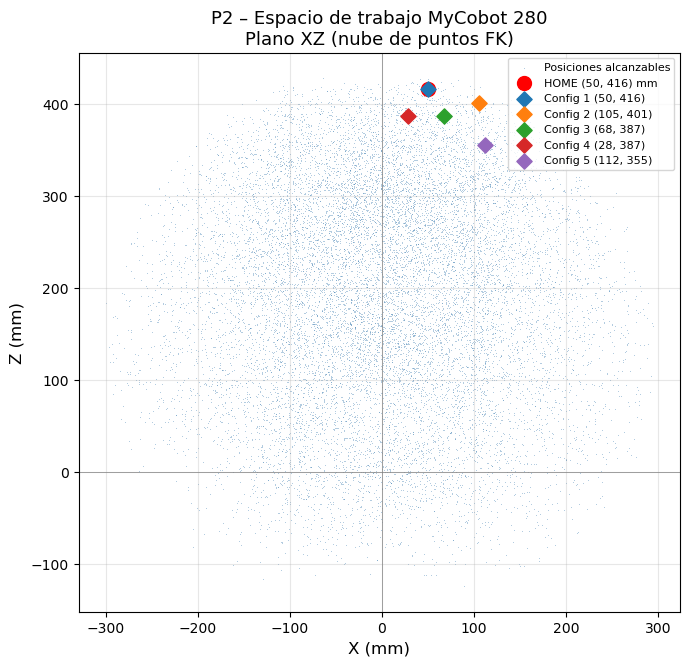

Gráfica guardada como espacio_trabajo_XZ.png


In [ ]:
# P2 – Ítem 5: Espacio de trabajo – nube de puntos en el plano XZ

N_SAMPLES = 15000
np.random.seed(42)

xs, zs = [], []
for _ in range(N_SAMPLES):
    cfg = [np.random.uniform(lo, hi) for (lo, hi) in JOINT_LIMITS]
    T   = forward_kinematics(cfg)
    x, _, z = get_xyz(T)
    xs.append(x)
    zs.append(z)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(xs, zs, s=0.5, alpha=0.3, color='steelblue', linewidths=0,
           label='Posiciones alcanzables')

# Marcar HOME
x_h, _, z_h = get_xyz(forward_kinematics([0,0,0,0,0,0]))
ax.scatter(x_h, z_h, s=100, color='red', zorder=5,
           label=f'HOME ({x_h:.0f}, {z_h:.0f}) mm')

# Marcar las 5 configs usadas en P2
for i, cfg in enumerate(CONFIGS):
    T = forward_kinematics(cfg)
    xc, _, zc = get_xyz(T)
    ax.scatter(xc, zc, s=60, zorder=5, marker='D',
               label=f'Config {i+1} ({xc:.0f}, {zc:.0f})')

ax.set_xlabel('X (mm)', fontsize=12)
ax.set_ylabel('Z (mm)', fontsize=12)
ax.set_title('P2 – Espacio de trabajo MyCobot 280\nPlano XZ (nube de puntos FK)', fontsize=13)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc='upper right')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.savefig('espacio_trabajo_XZ.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada como espacio_trabajo_XZ.png')

---
## Resumen de entregables

| Ítem | Tarea | Entregable |
|------|-------|------------|
| P1.1 | 6 sistemas de referencia DH | Tabla en markdown |
| P1.2 | Tabla de parámetros DH | `df_dh` |
| P1.3 | Matrices Ti por joint | Impresión de T1..T6 en HOME |
| P1.4 | Verificación T06 en HOME | Error FK vs robot real en mm |
| P1.5 | Significado físico | Descripción por joint |
| P2.1 | Implementar T06 con numpy | `forward_kinematics()` |
| P2.2 | FK para 5 configuraciones | `df_fk` |
| P2.3 | Comparar con robot real | `df_comp` con error en mm |
| P2.4 | Fuentes de discrepancia | `df_disc` |
| P2.5 | Espacio de trabajo XZ | `espacio_trabajo_XZ.png` |